# Week 17 — Wednesday–Thursday (Jul 16-17): MAE & Foundation Models

## Learning Objectives
- Understand Masked Autoencoders (MAE) — randomly mask a large fraction of image patches and train an encoder-decoder to reconstruct only the missing pixels, the image analogue of BERT's masked-language-modelling
- Understand why MAE's **asymmetric** design (a large encoder that only ever sees the small visible-patch subset + a lightweight decoder that is discarded after pretraining) makes pretraining efficient
- Understand why a very **high** masking ratio (~75%) works for images, unlike the ~15% typical for masked language modelling
- Understand DINOv2 as a scaled-up foundation model — self-distillation (Notebook 1) plus a masked-patch objective, trained on curated web-scale data, producing frozen features that transfer without fine-tuning
- Understand vision-language foundation models (CLIP-style) at a conceptual level — a shared image/text embedding space that enables zero-shot classification
- Implement lightweight patch masking and a small MAE encoder-decoder, and visualize masked-patch reconstructions

## Key Concepts
1. **Masked image modelling** — mask random patches, reconstruct them from the visible ones; a self-supervised pretext task like Notebook 1's contrastive views, but generative instead of discriminative
2. **Asymmetric encoder/decoder** — encoder only processes visible tokens (~25% of patches at 75% masking); decoder is small and thrown away after pretraining
3. **High masking ratio** — images are spatially redundant (a missing patch is often predictable from its neighbours), so a much higher mask ratio than text is needed to make the task non-trivial
4. **DINOv2** — self-distillation (DINO) + masked patch prediction (iBOT-style) at scale, on curated data, producing features usable *frozen* across many downstream tasks
5. **Vision-language models (CLIP-style)** — contrastive pretraining across image/text pairs, enabling zero-shot classification via cosine similarity to text prompts


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Week 17 — MAE & Foundation Models')

PyTorch 2.12.0+cpu | Device: cpu
Week 17 — MAE & Foundation Models


## Section 1: Masked Image Modelling — BERT for Images

MAE (He et al., 2021) applies BERT's masked-token pretraining idea to images:

```
 Image                Patchify              Random mask (75%)         Encoder            Decoder
┌────────┐         ┌─┬─┬─┬─┐             ┌─┬─┬─┬─┐              sees ONLY         reconstructs
│        │  split   │1│2│3│4│   mask 75%  │1│▓│▓│4│    ──────►   the visible      ALL patches
│  image │ ───────► ├─┼─┼─┼┤  ─────────►  ├─┼─┼─┼┤               patches (1,4,..)  (mask tokens +
│        │          │5│6│7│8│             │▓│6│▓│▓│                                positions for
└────────┘          └─┴─┴─┴┘             └─┴─┴─┴┘                                  the masked ones)
```

Only the reconstruction error on the **masked** patches contributes to the loss — the model
is never rewarded for "predicting" pixels it can already see. This forces the encoder to
build representations that capture enough *global* structure to hallucinate large missing
regions, not just copy local pixels.


## Section 2: Patchify + Random Masking, Visualised

Before building the model, let's implement patchify + masking on a real image and look at
what a 75%-masked image actually looks like.


In [2]:
# ── Load one real image (FashionMNIST, 28x28 grayscale) and patchify it ────────
# (CIFAR-10's usual host measured well under 100kB/s from this machine — confirmed
# empirically in Notebook 1 — so we use the same fast, reliable FashionMNIST substitute.)
PATCH_SIZE = 4
IMG_SIZE = 28
N_PATCHES_SIDE = IMG_SIZE // PATCH_SIZE          # 7
N_PATCHES = N_PATCHES_SIDE ** 2                  # 49
N_CHANNELS = 1

demo_ds = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True,
                                             transform=transforms.ToTensor())
demo_img, demo_label = demo_ds[7]                # (1, 28, 28)
print(f'Image shape: {tuple(demo_img.shape)} | patch size: {PATCH_SIZE} | '
      f'{N_PATCHES_SIDE}x{N_PATCHES_SIDE} = {N_PATCHES} patches')

def patchify(img, patch_size=PATCH_SIZE):
    """(C,H,W) -> (N_patches, C*patch_size*patch_size)"""
    C, H, W = img.shape
    p = patch_size
    patches = img.unfold(1, p, p).unfold(2, p, p)           # (C, H/p, W/p, p, p)
    patches = patches.permute(1, 2, 0, 3, 4).reshape(-1, C * p * p)
    return patches

def unpatchify(patches, patch_size=PATCH_SIZE, grid_side=N_PATCHES_SIDE, channels=N_CHANNELS):
    """(N_patches, C*p*p) -> (C,H,W)"""
    p = patch_size
    patches = patches.reshape(grid_side, grid_side, channels, p, p)
    img = patches.permute(2, 0, 3, 1, 4).reshape(channels, grid_side * p, grid_side * p)
    return img

patches = patchify(demo_img)
recon_check = unpatchify(patches)
print(f'Patchify -> {tuple(patches.shape)} | unpatchify round-trip matches original: '
      f'{torch.allclose(recon_check, demo_img)}')

Image shape: (1, 28, 28) | patch size: 4 | 7x7 = 49 patches
Patchify -> (49, 16) | unpatchify round-trip matches original: True


13 visible patches, 36 masked patches (75% masked)


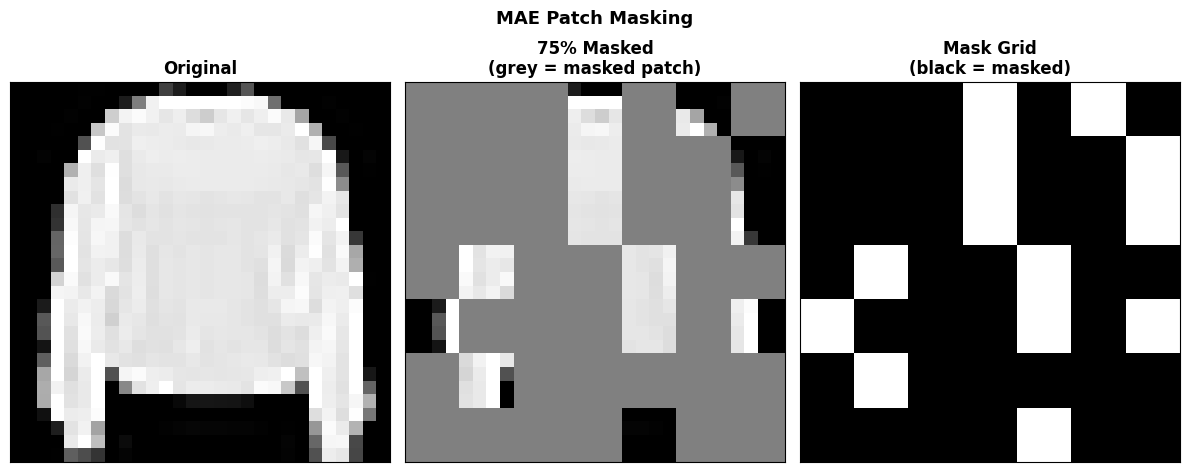

Saved mae_masking_demo.png


In [3]:
# ── Random 75% masking, visualised ─────────────────────────────────────────────
MASK_RATIO = 0.75

def random_mask(n_patches, mask_ratio, generator=None):
    """Returns (visible_idx, masked_idx) — a random split of patch indices."""
    n_masked = int(n_patches * mask_ratio)
    perm = torch.randperm(n_patches, generator=generator)
    masked_idx, visible_idx = perm[:n_masked], perm[n_masked:]
    return visible_idx, masked_idx

torch.manual_seed(1)
visible_idx, masked_idx = random_mask(N_PATCHES, MASK_RATIO)
print(f'{len(visible_idx)} visible patches, {len(masked_idx)} masked patches '
      f'({MASK_RATIO*100:.0f}% masked)')

masked_patches_vis = patches.clone()
masked_patches_vis[masked_idx] = 0.5   # grey out masked patches for visualisation
masked_img = unpatchify(masked_patches_vis)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.5))
axes[0].imshow(demo_img[0].numpy(), cmap='gray', vmin=0, vmax=1); axes[0].set_title('Original', fontweight='bold')
axes[1].imshow(masked_img[0].numpy(), cmap='gray', vmin=0, vmax=1); axes[1].set_title(f'{MASK_RATIO*100:.0f}% Masked\n(grey = masked patch)', fontweight='bold')
grid_vis = np.zeros((N_PATCHES_SIDE, N_PATCHES_SIDE))
for idx in masked_idx:
    grid_vis[idx // N_PATCHES_SIDE, idx % N_PATCHES_SIDE] = 1
axes[2].imshow(grid_vis, cmap='Greys'); axes[2].set_title('Mask Grid\n(black = masked)', fontweight='bold')
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('MAE Patch Masking', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('mae_masking_demo.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved mae_masking_demo.png')

## Section 3: Building a Lightweight MAE

Real MAE uses a full Vision Transformer for both encoder and decoder. We use tiny
Transformer stacks (2 encoder layers, 2 decoder layers, small hidden dim) — enough to
demonstrate the masking mechanism and watch reconstruction improve, while staying fast on
CPU. The pipeline per image:

1. Patchify into `PATCH_SIZE x PATCH_SIZE` patches, linearly embed each into `EMBED_DIM`
2. Add learned positional embeddings, **keep only the visible patches**, run them through
   the (small) Transformer encoder
3. Insert a learned **mask token** (same vector, broadcast) at every masked position, add
   positional embeddings again, run the full sequence through the (small) Transformer decoder
4. Linearly project each decoder output back to `PATCH_SIZE*PATCH_SIZE*3` pixel values
5. Loss = MSE between predicted and true pixel values, **only at masked positions**


In [4]:
# ── MAE model ────────────────────────────────────────────────────────────────
EMBED_DIM = 64
DECODER_DIM = 48
PATCH_DIM = PATCH_SIZE * PATCH_SIZE * N_CHANNELS   # 16

class MAE(nn.Module):
    def __init__(self, n_patches=N_PATCHES, patch_dim=PATCH_DIM,
                 embed_dim=EMBED_DIM, decoder_dim=DECODER_DIM,
                 enc_layers=2, dec_layers=2, n_heads=4):
        super().__init__()
        self.n_patches = n_patches

        self.patch_embed = nn.Linear(patch_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, n_patches, embed_dim) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(embed_dim, n_heads, dim_feedforward=embed_dim * 2,
                                                batch_first=True, activation='gelu')
        self.encoder = nn.TransformerEncoder(enc_layer, enc_layers)

        self.enc_to_dec = nn.Linear(embed_dim, decoder_dim)
        self.mask_token = nn.Parameter(torch.randn(1, 1, decoder_dim) * 0.02)
        self.decoder_pos_embed = nn.Parameter(torch.randn(1, n_patches, decoder_dim) * 0.02)
        dec_layer = nn.TransformerEncoderLayer(decoder_dim, n_heads, dim_feedforward=decoder_dim * 2,
                                                batch_first=True, activation='gelu')
        self.decoder = nn.TransformerEncoder(dec_layer, dec_layers)
        self.decoder_pred = nn.Linear(decoder_dim, patch_dim)

    def forward(self, patches, visible_idx, masked_idx):
        """patches: (B, N, patch_dim). visible_idx/masked_idx: (N_vis,)/(N_mask,) shared
        across the batch (same random mask applied to every image in the batch)."""
        B = patches.size(0)
        x = self.patch_embed(patches) + self.pos_embed                 # (B, N, embed_dim)

        x_vis = x[:, visible_idx, :]                                    # (B, N_vis, embed_dim)
        enc_out = self.encoder(x_vis)                                   # (B, N_vis, embed_dim)
        enc_out = self.enc_to_dec(enc_out)                              # (B, N_vis, decoder_dim)

        full = torch.zeros(B, self.n_patches, enc_out.size(-1), device=patches.device)
        full[:, visible_idx, :] = enc_out
        full[:, masked_idx, :] = self.mask_token
        full = full + self.decoder_pos_embed

        dec_out = self.decoder(full)                                    # (B, N, decoder_dim)
        pred = self.decoder_pred(dec_out)                               # (B, N, patch_dim)
        return pred


mae = MAE().to(DEVICE)
n_params = sum(p.numel() for p in mae.parameters())
print(f'MAE params: {n_params:,}')

# quick forward-shape check
test_patches = patches.unsqueeze(0).to(DEVICE)
vis_t, mask_t = visible_idx.to(DEVICE), masked_idx.to(DEVICE)
test_pred = mae(test_patches, vis_t, mask_t)
print(f'Input patches {tuple(test_patches.shape)} -> predicted patches {tuple(test_pred.shape)}')

MAE params: 115,392
Input patches (1, 49, 16) -> predicted patches (1, 49, 16)


## Section 4: Training MAE on a Small Image Set

Same small FashionMNIST subset idea as Notebook 1. Every batch gets a **fresh random mask**
(75% of patches), and the loss only looks at the masked positions.


In [5]:
# ── Small FashionMNIST subset (reuses the ./data cache from Notebook 1 if present) ──
N_TRAIN = 800
mae_ds_full = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True,
                                                 transform=transforms.ToTensor())
mae_train_ds = torch.utils.data.Subset(mae_ds_full, list(range(N_TRAIN)))
mae_train_dl = DataLoader(mae_train_ds, batch_size=64, shuffle=True, drop_last=True)
print(f'MAE training set: {N_TRAIN} images, batch size 64, {len(mae_train_dl)} batches/epoch')

def batch_patchify(imgs, patch_size=PATCH_SIZE):
    """(B,C,H,W) -> (B, N_patches, C*p*p)"""
    B, C, H, W = imgs.shape
    p = patch_size
    x = imgs.unfold(2, p, p).unfold(3, p, p)                # (B,C,H/p,W/p,p,p)
    x = x.permute(0, 2, 3, 1, 4, 5).reshape(B, -1, C * p * p)
    return x

test_batch, _ = next(iter(mae_train_dl))
print(f'batch_patchify check: {tuple(test_batch.shape)} -> {tuple(batch_patchify(test_batch).shape)}')

MAE training set: 800 images, batch size 64, 12 batches/epoch
batch_patchify check: (64, 1, 28, 28) -> (64, 49, 16)


In [6]:
# ── MAE training loop ────────────────────────────────────────────────────────
N_EPOCHS = 25
LR = 1e-3
mae_opt = torch.optim.Adam(mae.parameters(), lr=LR)
mae_loss_history = []

for epoch in range(1, N_EPOCHS + 1):
    mae.train()
    epoch_losses = []
    for imgs, _ in mae_train_dl:
        imgs = imgs.to(DEVICE)
        batch_patches = batch_patchify(imgs)

        vis_idx, msk_idx = random_mask(N_PATCHES, MASK_RATIO)    # fresh mask every batch
        vis_idx, msk_idx = vis_idx.to(DEVICE), msk_idx.to(DEVICE)

        pred = mae(batch_patches, vis_idx, msk_idx)
        loss = F.mse_loss(pred[:, msk_idx, :], batch_patches[:, msk_idx, :])

        mae_opt.zero_grad(); loss.backward(); mae_opt.step()
        epoch_losses.append(loss.item())

    mae_loss_history.append(np.mean(epoch_losses))
    if epoch == 1 or epoch % 5 == 0 or epoch == N_EPOCHS:
        print(f'Epoch {epoch:2d}/{N_EPOCHS} | masked-patch MSE: {mae_loss_history[-1]:.4f}')

print(f'\nReconstruction loss fell from {mae_loss_history[0]:.4f} to {mae_loss_history[-1]:.4f}')

Epoch  1/25 | masked-patch MSE: 0.1866


Epoch  5/25 | masked-patch MSE: 0.1123


Epoch 10/25 | masked-patch MSE: 0.0858


Epoch 15/25 | masked-patch MSE: 0.0757


Epoch 20/25 | masked-patch MSE: 0.0821


Epoch 25/25 | masked-patch MSE: 0.0749

Reconstruction loss fell from 0.1866 to 0.0749


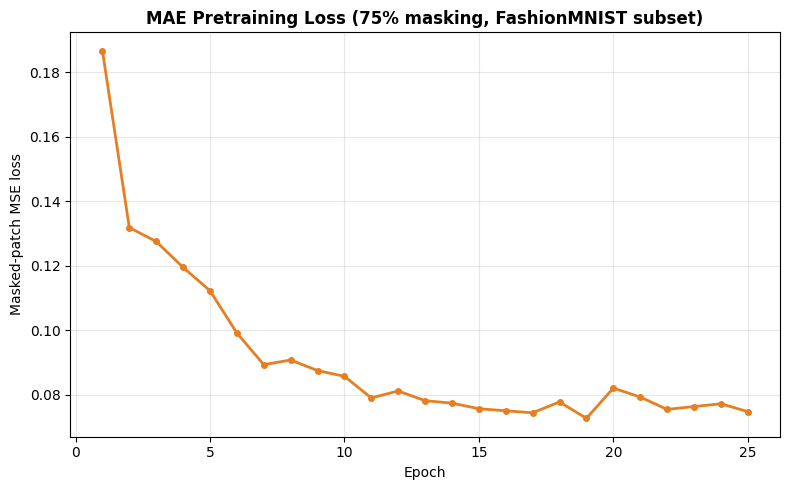

Saved mae_loss_curve.png


In [7]:
# ── Loss curve ──────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(range(1, N_EPOCHS + 1), mae_loss_history, color='#e67e22', lw=2, marker='o', ms=4)
plt.xlabel('Epoch'); plt.ylabel('Masked-patch MSE loss')
plt.title('MAE Pretraining Loss (75% masking, FashionMNIST subset)', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mae_loss_curve.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved mae_loss_curve.png')

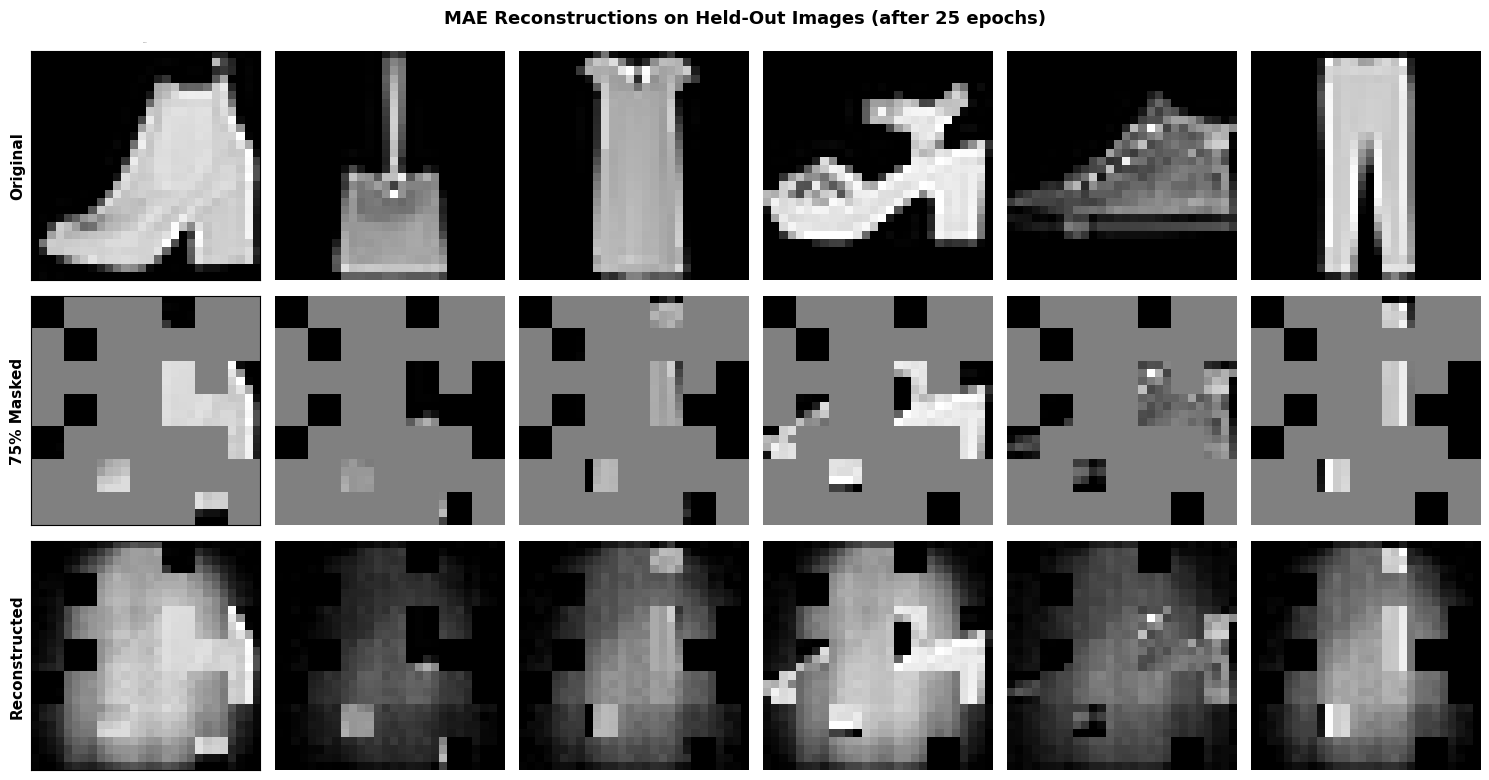

Saved mae_reconstructions.png
Reconstructions are blurry (tiny model, few epochs, 28x28 images) but recover overall
colour/shape structure of the masked regions from the 25% visible context — the mechanism works.


In [8]:
# ── Visualise reconstructions on held-out images ───────────────────────────────
mae.eval()
val_imgs = torch.stack([mae_ds_full[i][0] for i in range(N_TRAIN, N_TRAIN + 6)]).to(DEVICE)
val_patches = batch_patchify(val_imgs)

torch.manual_seed(123)
vis_idx, msk_idx = random_mask(N_PATCHES, MASK_RATIO)
vis_idx, msk_idx = vis_idx.to(DEVICE), msk_idx.to(DEVICE)

with torch.no_grad():
    pred_patches = mae(val_patches, vis_idx, msk_idx)

# stitch: visible patches = ground truth, masked patches = model's prediction
recon_patches = val_patches.clone()
recon_patches[:, msk_idx, :] = pred_patches[:, msk_idx, :]

masked_vis_patches = val_patches.clone()
masked_vis_patches[:, msk_idx, :] = 0.5

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for col in range(6):
    orig = val_imgs[col].cpu()
    masked = unpatchify(masked_vis_patches[col].cpu())
    recon = unpatchify(recon_patches[col].cpu()).clamp(0, 1)
    axes[0, col].imshow(orig[0].numpy(), cmap='gray', vmin=0, vmax=1); axes[0, col].axis('off')
    axes[1, col].imshow(masked[0].numpy(), cmap='gray', vmin=0, vmax=1); axes[1, col].axis('off')
    axes[2, col].imshow(recon[0].numpy(), cmap='gray', vmin=0, vmax=1); axes[2, col].axis('off')
axes[0, 0].set_title('col 0', fontsize=0)  # placeholder to keep layout consistent
for ax, row_label in zip(axes[:, 0], ['Original', f'{int(MASK_RATIO*100)}% Masked', 'Reconstructed']):
    ax.set_ylabel(row_label, fontsize=11, fontweight='bold')
    ax.axis('on'); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f'MAE Reconstructions on Held-Out Images (after {N_EPOCHS} epochs)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('mae_reconstructions.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved mae_reconstructions.png')
print('Reconstructions are blurry (tiny model, few epochs, 28x28 images) but recover overall')
print('colour/shape structure of the masked regions from the 25% visible context — the mechanism works.')

## Section 5: Why the Asymmetric Design and High Mask Ratio Matter

**Compute savings.** At 75% masking, the (larger, more expensive) encoder only ever
processes 25% of the tokens. The decoder, which processes the *full* sequence including
mask tokens, is kept deliberately small and shallow, and — critically — is **discarded
after pretraining**. Only the encoder is reused downstream. Net effect: pretraining an MAE
encoder is roughly 3-4x cheaper than pretraining the same encoder with a scheme that has to
look at every token.

**Why 75%, not 15% like BERT?** Natural images are highly spatially redundant — a missing
patch can often be interpolated from its neighbours (smooth regions, repeated textures).
At a low mask ratio the task is nearly trivial (a blur/inpainting filter would do). A very
high mask ratio removes enough local context that the model is forced to learn *global*
semantic structure (what kind of object/scene is this?) to fill in the gaps — text tokens
carry far more information per token, so a much lower mask ratio (~15%) already makes
BERT's cloze task hard.

**What survives after pretraining.** Just the encoder — fine-tuned or used frozen as a
feature extractor for downstream tasks (classification, detection, segmentation). This is
the same "throw away the pretext-task scaffolding, keep the backbone" pattern seen with
SimCLR/MoCo/DINO in Notebook 1.


## Section 6: DINOv2 & Vision Foundation Models

**DINOv2** (Oquab et al., 2023) combines the ideas from this week into one recipe, scaled up:

| Ingredient | From |
|---|---|
| Student/teacher self-distillation, EMA teacher, centering | DINO (Notebook 1) |
| Masked-patch prediction loss (iBOT-style) alongside the image-level distillation loss | MAE (this notebook) |
| A large, automatically **curated** (deduplicated, diverse) web-scale image dataset (LVD-142M) | new to DINOv2 |
| ViT-S/B/L/g backbones, trained with extensive engineering for stability at scale | new to DINOv2 |

The result is a **foundation model**: a single frozen backbone whose patch- and
image-level features transfer, *without any fine-tuning*, to classification (linear probe
or k-NN), semantic segmentation, depth estimation, and image retrieval — often matching or
beating task-specific supervised models. This is precisely the property Friday's project
exploits: **frozen features + a tiny classifier head** on top.

> **CPU/time note:** true DINOv2 checkpoints (even the smallest, ViT-S/14, ~21M params) are
> fetched via `torch.hub.load('facebookresearch/dinov2', ...)`, which pulls a few hundred MB
> and additional dependencies. To keep this repo's environment fast and dependency-light on
> CPU, Friday's project substitutes a **torchvision ImageNet-pretrained ResNet-18** as the
> frozen backbone — smaller and quicker to fetch, but playing the *exact same architectural
> role* (frozen general-purpose feature extractor) that DINOv2 would play. The substitution
> is called out explicitly there.


## Section 7: Vision-Language Foundation Models (CLIP-style)

CLIP (Radford et al., 2021) trains an image encoder and a text encoder **jointly**, with a
contrastive loss across image-text pairs scraped from the web: for a batch of $N$
(image, caption) pairs, the loss is (again!) an NT-Xent-style softmax classification —
"which of the $N$ captions in this batch matches this image?" — computed in *both*
directions (image→text and text→image).

Once trained, the two towers share an embedding space, which enables **zero-shot
classification** with no task-specific training data at all:

1. Embed the query image: $z_{img} = f_{image}(x)$
2. Embed each candidate class as a text prompt, e.g. `"a photo of a {class}"`: $z_k = f_{text}(\text{prompt}_k)$
3. Predict the class whose text embedding is most similar: $\hat{y} = \arg\max_k \cos(z_{img}, z_k)$

The toy snippet below illustrates *only the final mechanism* (cosine similarity + softmax
over prompts) with random vectors standing in for real CLIP embeddings — no real CLIP
weights are downloaded here.


In [9]:
# ── Toy illustration of CLIP-style zero-shot classification (NOT real CLIP weights) ──
torch.manual_seed(7)
EMBED = 32
class_names_clip = ['cat', 'dog', 'airplane', 'ship']

# Pretend these came from a trained image encoder / text encoder; here just random unit vectors
# nudged so 'cat' text and the query image are deliberately close, to show the mechanism.
text_embeds = F.normalize(torch.randn(len(class_names_clip), EMBED), dim=1)
image_embed = F.normalize(text_embeds[0] + 0.3 * torch.randn(EMBED), dim=0)   # closest to 'cat'

sims = image_embed @ text_embeds.t()                 # cosine similarities (already unit norm)
probs = F.softmax(sims / 0.07, dim=0)                 # CLIP uses a learned temperature ~0.07

print('Zero-shot classification via image-text cosine similarity (toy vectors):')
for name, sim, prob in sorted(zip(class_names_clip, sims.tolist(), probs.tolist()),
                               key=lambda t: -t[2]):
    print(f'  "a photo of a {name}":  cos_sim={sim:+.3f}  ->  P={prob:.3f}')
print(f'\nPredicted class: "{class_names_clip[probs.argmax().item()]}"  '
      f'(no classifier was ever trained for this task — just nearest text prompt)')

Zero-shot classification via image-text cosine similarity (toy vectors):
  "a photo of a cat":  cos_sim=+0.675  ->  P=1.000
  "a photo of a ship":  cos_sim=+0.046  ->  P=0.000
  "a photo of a airplane":  cos_sim=+0.031  ->  P=0.000
  "a photo of a dog":  cos_sim=-0.329  ->  P=0.000

Predicted class: "cat"  (no classifier was ever trained for this task — just nearest text prompt)


## Summary

- **MAE** masks a high fraction (75%) of image patches and reconstructs only the missing
  pixels — a generative self-supervised task, complementary to contrastive learning
- The **asymmetric encoder/decoder** (encoder sees only visible tokens, decoder is small and
  discarded) makes pretraining efficient; the high mask ratio is necessary because natural
  images are spatially redundant
- **DINOv2** fuses self-distillation (DINO) with masked-patch prediction (MAE-like) and
  scales both up with curated web data, producing genuinely general-purpose frozen features
- **CLIP-style vision-language models** extend the contrastive recipe from Notebook 1 across
  modalities, enabling zero-shot classification via image-text cosine similarity
- Every method this week converges on the same downstream artifact: a **frozen backbone**
  whose features are reused directly — which is exactly what Friday's project builds on

**Next (Jul 20): Project — 5-Shot Classifier with DINOv2 Features** — using a frozen
pretrained backbone's embeddings with a simple nearest-centroid / k-NN classifier for
few-shot image classification.
